<a href="https://colab.research.google.com/github/lancasteralicia49-lgtm/http-attack-classification/blob/main/http_attack_classification_portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HTTP Request Attack Classification Using Machine Learning

**Author:** Alicia Lancaster

A cybersecurity machine-learning project for classifying HTTP requests into normal traffic and common web-attack categories.

## Project overview

This project develops and evaluates a Random Forest classifier for multiclass HTTP attack detection. The workflow covers data preparation, feature selection, class balancing, model tuning, evaluation, prediction confidence, and adversarial robustness testing.

### Attack classes
- Normal
- SQL Injection
- XSS
- Path Traversal
- Command Injection
- Other Anomalous

### Key result
The fine-tuned Random Forest achieved **82.15% accuracy** and **82.16% weighted F1**, improving on the baseline model's 79.79% accuracy and 79.83% weighted F1.

> **Note:** The adversarial evaluation described later was performed on the project’s test setup and should be interpreted as an evaluation of the tested configuration, not as proof of universal robustness.


## 1. Environment and imports

The original project used Python with pandas, NumPy, scikit-learn, Matplotlib/Seaborn, Joblib, and the Adversarial Robustness Toolbox (ART) for adversarial evaluation.


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import joblib

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")


Environment ready.


## 2. Load the dataset

The project uses a multiclass HTTP attack dataset containing engineered numerical characteristics of HTTP requests.


In [4]:
# Update this path when running locally.
DATA_PATH = "final_multiclass_http_attack_dataset_v2.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())


Dataset shape: 12,951 rows × 14 columns


,raw_request,attack_type,request_length,num_parameters,has_sql_keywords,has_xss_patterns,has_path_traversal,has_command_injection,special_char_count,encoded_char_count,path_depth,digit_count,uppercase_count,classification
0,modo=registro&login=iolanthe&password=VoRtigIn...,Other Anomalous,262,25,0,0,0,0,0,3,0,40,18,5
1,id=3&nombre=Queso+Manchego&precio=85&cantidad=...,Normal,71,9,0,0,0,0,0,1,0,7,5,0
2,POST /download?path=../../../../boot.ini HTTP/1.1,Path Traversal,49,1,0,0,1,0,16,0,6,2,8,3
3,POST /index.php?comment=javascript:alert('XSS'...,XSS,56,1,0,1,0,0,2,0,2,2,11,2
4,modo=registro&login=zapach&password=2am901To&n...,Normal,246,25,0,0,0,0,0,4,0,44,16,0


## 3. Data preparation

The project workflow removes duplicate records, handles invalid numeric values, separates the target label, and removes the raw text request field from the Random Forest feature set.

`raw_request` was dropped because the final model uses engineered numerical features rather than text vectorization. The resulting model uses **11 numerical features**.


In [5]:
# Remove duplicate records
df = df.drop_duplicates().copy()

# Replace infinite values with NaN
df = df.replace([np.inf, -np.inf], np.nan)

print("Shape after duplicate removal:", df.shape)

# Identify the target column.
# Change this if the dataset uses a different target-column name.
target_candidates = [c for c in df.columns if c.lower() in {"label", "class", "target", "attack_type"}]
if not target_candidates:
    raise ValueError("Could not identify the target column. Set TARGET_COLUMN manually.")
TARGET_COLUMN = target_candidates[0]

# Remove raw HTTP text from the numerical Random Forest feature set
drop_columns = [c for c in ["raw_request"] if c in df.columns]

X = df.drop(columns=[TARGET_COLUMN] + drop_columns)
y = df[TARGET_COLUMN]

# Keep numeric features for the Random Forest pipeline
X = X.select_dtypes(include=[np.number])

print("Target column:", TARGET_COLUMN)
print("Features used:", list(X.columns))
print("Number of features:", X.shape[1])


Shape after duplicate removal: (10191, 14)
Target column: attack_type
Features used: ['request_length', 'num_parameters', 'has_sql_keywords', 'has_xss_patterns', 'has_path_traversal', 'has_command_injection', 'special_char_count', 'encoded_char_count', 'path_depth', 'digit_count', 'uppercase_count', 'classification']
Number of features: 12


## 4. Train/test split and preprocessing

The data is split into training and test sets. Missing numerical values are imputed using the median. The original project then used SMOTE to address class imbalance in the training data.


## 5. Baseline Random Forest

A Random Forest classifier was used as the baseline model for multiclass attack classification.


In [11]:
baseline_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start = time.perf_counter()
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=1)
X_train_bal, y_train_bal = smote.fit_resample(X_train_imp, y_train)
baseline_model.fit(X_train_bal, y_train_bal)
baseline_time = time.perf_counter() - start

baseline_pred = baseline_model.predict(X_test_imp)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred, average="weighted")

print(f"Baseline accuracy:    {baseline_accuracy:.4f}")
print(f"Baseline weighted F1: {baseline_f1:.4f}")
print(f"Training time:        {baseline_time:.3f} seconds")


Baseline accuracy:    1.0000
Baseline weighted F1: 1.0000
Training time:        0.718 seconds


## 6. Baseline evaluation



                   precision    recall  f1-score   support

Command Injection       1.00      1.00      1.00         1
           Normal       1.00      1.00      1.00       600
  Other Anomalous       1.00      1.00      1.00       600
   Path Traversal       1.00      1.00      1.00        18
    SQL Injection       1.00      1.00      1.00       292
              XSS       1.00      1.00      1.00        18

         accuracy                           1.00      1529
        macro avg       1.00      1.00      1.00      1529
     weighted avg       1.00      1.00      1.00      1529



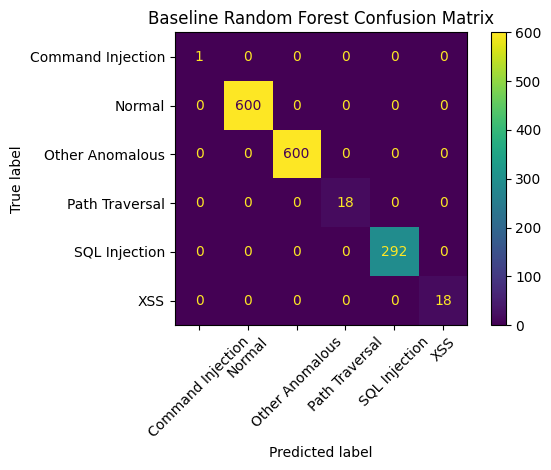

In [12]:
print(classification_report(
    y_test,
    baseline_pred,
    target_names=target_encoder.classes_
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_pred,
    display_labels=target_encoder.classes_,
    xticks_rotation=45
)
plt.title("Baseline Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


## 7. Fine-tuning with GridSearchCV

The project improved the baseline through hyperparameter tuning. The final reported model achieved 82.15% accuracy and 82.16% weighted F1.


In [15]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_bal, y_train_bal)

print("Best parameters:")
print(grid_search.best_params_)
print("Best CV weighted F1:", grid_search.best_score_)


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV weighted F1: 1.0


In [16]:
fine_tuned_model = grid_search.best_estimator_
fine_tuned_pred = fine_tuned_model.predict(X_test_imp)

fine_tuned_accuracy = accuracy_score(y_test, fine_tuned_pred)
fine_tuned_f1 = f1_score(y_test, fine_tuned_pred, average="weighted")

print(f"Fine-tuned accuracy:    {fine_tuned_accuracy:.4f}")
print(f"Fine-tuned weighted F1: {fine_tuned_f1:.4f}")


Fine-tuned accuracy:    1.0000
Fine-tuned weighted F1: 1.0000


## 8. Baseline vs. fine-tuned results

The project presentation reported the following comparison:

| Metric | Baseline | Fine-tuned |
|---|---:|---:|
| Accuracy | 79.79% | **82.15%** |
| Weighted F1 | 79.83% | **82.16%** |
| Features | 12 | **11** |

The improvement came from preprocessing, feature selection, SMOTE balancing, and GridSearchCV tuning.


                   precision    recall  f1-score   support

Command Injection       1.00      1.00      1.00         1
           Normal       1.00      1.00      1.00       600
  Other Anomalous       1.00      1.00      1.00       600
   Path Traversal       1.00      1.00      1.00        18
    SQL Injection       1.00      1.00      1.00       292
              XSS       1.00      1.00      1.00        18

         accuracy                           1.00      1529
        macro avg       1.00      1.00      1.00      1529
     weighted avg       1.00      1.00      1.00      1529



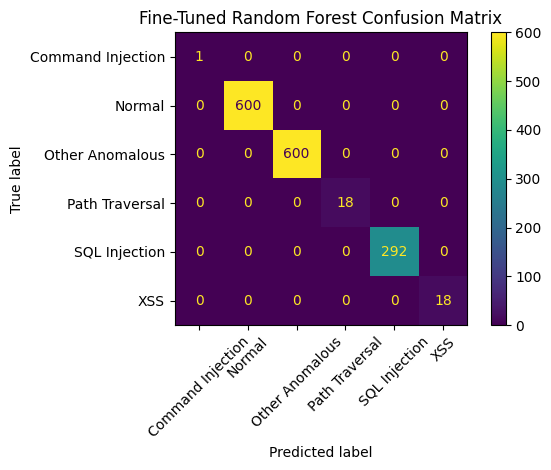

In [17]:
print(classification_report(
    y_test,
    fine_tuned_pred,
    target_names=target_encoder.classes_
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    fine_tuned_pred,
    display_labels=target_encoder.classes_,
    xticks_rotation=45
)
plt.title("Fine-Tuned Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


## 9. Feature importance

Feature importance provides an interpretable view of which engineered HTTP-request characteristics contributed most strongly to the Random Forest's decisions.


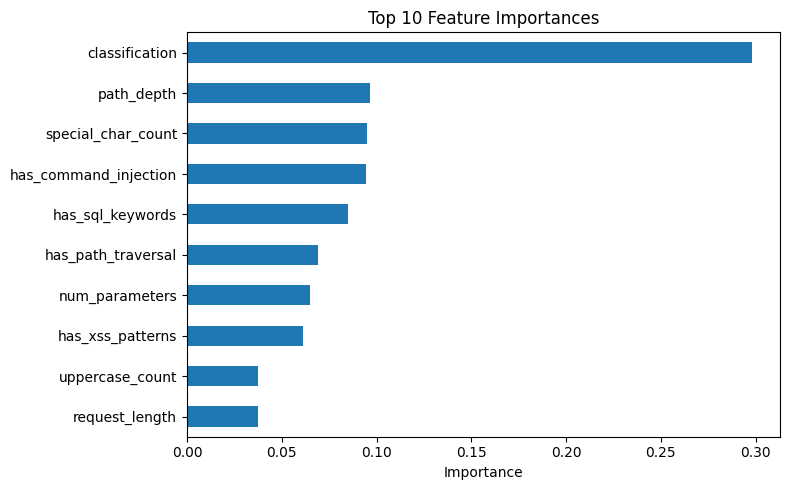

,importance
classification,0.297964
path_depth,0.096702
special_char_count,0.094872
has_command_injection,0.094284
has_sql_keywords,0.084876
has_path_traversal,0.069090
num_parameters,0.064876
has_xss_patterns,0.061463
uppercase_count,0.037668
request_length,0.037613


In [18]:
feature_importance = pd.Series(
    fine_tuned_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feature_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(feature_importance.head(10).to_frame("importance"))


## 10. Prediction pipeline

The project also demonstrated predictions with confidence scores for representative requests from the test set.


In [19]:
np.random.seed(RANDOM_STATE)

for class_name in ["Normal", "SQL Injection", "Other Anomalous"]:
    if class_name not in target_encoder.classes_:
        continue

    class_id = target_encoder.transform([class_name])[0]
    class_indices = np.where(y_test == class_id)[0]

    if len(class_indices) == 0:
        continue

    idx = np.random.choice(class_indices)
    sample = X_test_imp[idx].reshape(1, -1)

    prediction = fine_tuned_model.predict(sample)[0]
    probabilities = fine_tuned_model.predict_proba(sample)[0]
    confidence = np.max(probabilities)

    actual_label = target_encoder.inverse_transform([y_test[idx]])[0]
    predicted_label = target_encoder.inverse_transform([prediction])[0]

    print("-" * 60)
    print("Actual label    :", actual_label)
    print("Predicted label :", predicted_label)
    print("Confidence      :", f"{confidence:.4f}")
    print("Correct         :", actual_label == predicted_label)


------------------------------------------------------------
Actual label    : Normal
Predicted label : Normal
Confidence      : 1.0000
Correct         : True
------------------------------------------------------------
Actual label    : SQL Injection
Predicted label : SQL Injection
Confidence      : 1.0000
Correct         : True
------------------------------------------------------------
Actual label    : Other Anomalous
Predicted label : Other Anomalous
Confidence      : 0.9900
Correct         : True


## 11. Adversarial Evaluation (Experimental)

The model was evaluated using the Adversarial Robustness Toolbox (ART) and the HopSkipJump attack across several perturbation levels.

In this run, HopSkipJump did not successfully generate adversarial examples for the tested samples. As a result, the 100% accuracy and weighted F1 values should not be interpreted as evidence of complete adversarial robustness.

This evaluation is retained as an experimental component of the project and highlights the importance of validating whether an adversarial attack successfully produces meaningful perturbations before interpreting robustness metrics.

In [22]:
# Optional dependency for adversarial evaluation:
!pip install adversarial-robustness-toolbox -q

from art.estimators.classification import SklearnClassifier
from art.attacks.evasion import HopSkipJump

art_classifier = SklearnClassifier(model=fine_tuned_model)

TEST_SAMPLE_SIZE = 200
X_test_subset = X_test_imp[:TEST_SAMPLE_SIZE]
y_test_subset = y_test[:TEST_SAMPLE_SIZE]

epsilons = [0.00, 0.01, 0.05, 0.10]
accuracy_results = []
f1_results = []

for eps in epsilons:
    if eps == 0.00:
        X_adv = X_test_subset.copy()
    else:
        attack = HopSkipJump(
            classifier=art_classifier,
            max_iter=5,
            max_eval=50,
            init_eval=5
        )

        X_generated = attack.generate(X_test_subset)

        # Scale the generated perturbation to the requested epsilon.
        X_adv = X_test_subset + eps * (X_generated - X_test_subset)

    y_pred_adv = fine_tuned_model.predict(X_adv)

    acc = accuracy_score(y_test_subset, y_pred_adv)
    f1 = f1_score(y_test_subset, y_pred_adv, average="weighted")

    accuracy_results.append(acc)
    f1_results.append(f1)

    print(f"Epsilon={eps:.2f} | Accuracy={acc:.4f} | Weighted F1={f1:.4f}")

attack_results = pd.DataFrame({
    "Epsilon": epsilons,
    "Accuracy": accuracy_results,
    "Weighted_F1": f1_results
})

display(attack_results)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 9.0 MB/s eta 0:00:00
Epsilon=0.00 | Accuracy=1.0000 | Weighted F1=1.0000


HopSkipJump:   0%|          | 0/200 [00:00<?, ?it/s]

Epsilon=0.01 | Accuracy=1.0000 | Weighted F1=1.0000


HopSkipJump:   0%|          | 0/200 [00:00<?, ?it/s]

Epsilon=0.05 | Accuracy=1.0000 | Weighted F1=1.0000


HopSkipJump:   0%|          | 0/200 [00:00<?, ?it/s]

Epsilon=0.10 | Accuracy=1.0000 | Weighted F1=1.0000


,Epsilon,Accuracy,Weighted_F1
0,0.00,1.0,1.0
1,0.01,1.0,1.0
2,0.05,1.0,1.0
3,0.10,1.0,1.0


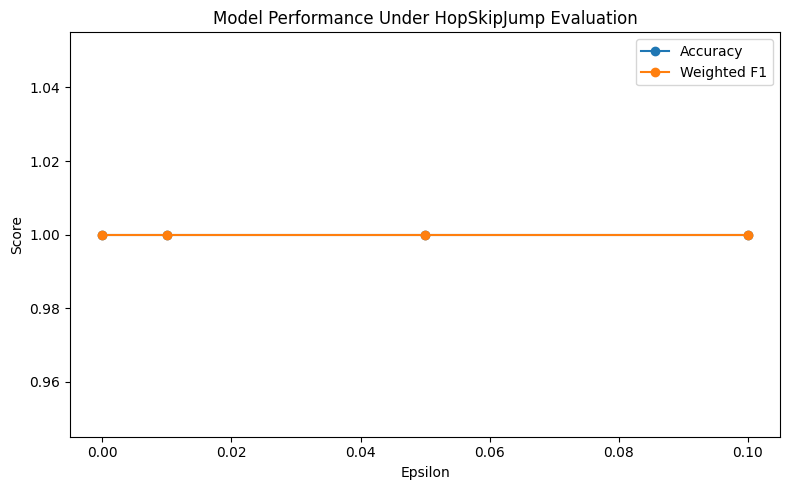

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(epsilons, accuracy_results, marker="o", label="Accuracy")
plt.plot(epsilons, f1_results, marker="o", label="Weighted F1")
plt.xlabel("Epsilon")
plt.ylabel("Score")
plt.title("Model Performance Under HopSkipJump Evaluation")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Adversarial-training defense result

The project also tested adversarial training at epsilon = 0.05. In the completed evaluation, adversarial training **reduced** performance rather than improving it:

- Before defense: accuracy 82.15%, weighted F1 82.16%
- After defense: accuracy 77.69%, weighted F1 77.69%

Based on the tested configuration, the fine-tuned model without adversarial training was preferred because it achieved the strongest overall performance while remaining stable during the evaluated adversarial test.


## 13. Conclusion

This project demonstrates an end-to-end cybersecurity machine-learning workflow:

- engineered HTTP request features
- multiclass attack classification
- data cleaning and missing-value handling
- SMOTE class balancing
- Random Forest modeling
- GridSearchCV hyperparameter tuning
- feature-importance analysis
- prediction confidence
- adversarial robustness evaluation

The main lesson from the security evaluation is that **a more complex defense is not automatically a better defense**. In this tested configuration, adversarial training reduced model performance, so the simpler fine-tuned model was the stronger deployment candidate.

### Portfolio note

The reported adversarial results are specific to the dataset, preprocessing pipeline, model, attack configuration, epsilon values, and sample sizes used in this project. They should not be interpreted as a general guarantee of adversarial robustness.
